# 2.4 Random Forest Optimization - 2010s

#### 1. Import libraries
#### 2. Load data
#### 3. Wrangle data
#### 4. Creates Random Forest model
#### 5. Feature importances

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn import metrics
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

#### 2. Load data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/7 Machine Learning/Notebooks/Dataset-weather-cleaned-2010s.csv')

In [ ]:
df.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,8,0.93,0.9965,0.18,0.56,0.0,2.9,-0.2,4.8,6,...,-7.0,1,0.80,1.0121,0.43,0.00,6.0,1.7,-1.6,5.0
1,3,0.74,1.0193,0.58,0.00,5.2,-1.5,-4.2,0.4,8,...,-7.1,1,0.82,1.0196,0.45,0.00,6.0,0.8,-4.5,6.2
2,3,0.75,1.0226,0.61,0.00,6.3,-3.2,-6.0,1.1,7,...,-7.1,4,0.71,1.0196,0.36,0.41,1.6,0.5,-4.1,5.1
3,5,0.83,1.0169,0.48,0.00,3.7,-4.9,-8.3,-3.1,2,...,-3.6,2,0.67,1.0219,0.48,0.51,6.5,3.7,1.3,3.8
4,7,0.78,1.0073,0.53,0.04,4.4,-4.0,-7.1,-1.5,6,...,-5.5,4,0.78,1.0117,0.45,0.09,4.7,2.3,-0.7,5.4


In [ ]:
df.shape

(3652, 135)

In [ ]:
dfa=pd.read_csv('/content/drive/MyDrive/7 Machine Learning/Notebooks/Dataset-Answers-2010s.csv')

In [ ]:
dfa.head()

,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
dfa.shape

(3652, 15)

#### 3. Wrangle data

In [ ]:
# Extract stations list

stations = [col.split('_')[0] for col in df.columns if '_' in col]

In [ ]:
# Create a set of unique station names

unique_stations = set(stations)
unique_stations

{'BASEL',
 'BELGRADE',
 'BUDAPEST',
 'DEBILT',
 'DUSSELDORF',
 'HEATHROW',
 'KASSEL',
 'LJUBLJANA',
 'MAASTRICHT',
 'MADRID',
 'MUNCHENB',
 'OSLO',
 'SONNBLICK',
 'STOCKHOLM',
 'VALENTIA'}

In [ ]:
# Create a dictionary to store the frequency of entries for each station
station_frequencies = {}

for station in unique_stations:
    # Select columns that belong to the current station
    station_columns = [col for col in  df.columns if col.startswith(station)]

    # Count non-missing entries across all columns for the station
    station_frequencies[station] =  df[station_columns].notna().sum().sum()

# Print the frequency of entries for each station
print("Frequency of entries for each weather station:")
for station, freq in station_frequencies.items():
    print(f"{station}: {freq} entries")

Frequency of entries for each weather station:
BASEL: 32868 entries
HEATHROW: 32868 entries
DEBILT: 32868 entries
BUDAPEST: 32868 entries
MUNCHENB: 32868 entries
LJUBLJANA: 32868 entries
KASSEL: 32868 entries
MAASTRICHT: 32868 entries
OSLO: 32868 entries
SONNBLICK: 32868 entries
MADRID: 32868 entries
BELGRADE: 32868 entries
VALENTIA: 32868 entries
DUSSELDORF: 32868 entries
STOCKHOLM: 32868 entries


In [ ]:
X = df
y = dfa

In [ ]:
# Turn X and y from a df to arrays

X = np.array(X)
y = np.array(y)

In [ ]:
X.shape

(3652, 135)

In [ ]:
y.shape

(3652, 15)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:

X_train = X_train.reshape(-1,135) #-1 means "whatever works"
print(X_train.shape)
X_train

(2739, 135)


array([[ 8.    ,  0.94  ,  1.0129, ..., 10.7   ,  7.9   , 10.7   ],
       [ 1.    ,  0.57  ,  1.0307, ..., 10.7   ,  7.9   , 13.5   ],
       [ 7.    ,  0.84  ,  1.014 , ..., 10.7   ,  7.9   , 13.5   ],
       ...,
       [ 7.    ,  0.71  ,  1.0208, ..., 10.7   ,  7.9   , 13.5   ],
       [ 5.    ,  0.64  ,  1.0103, ..., 10.7   ,  7.9   , 13.5   ],
       [ 5.    ,  0.52  ,  1.0231, ..., 10.7   ,  7.9   , 13.5   ]])

In [ ]:
y_train

array([[0, 1, 1, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]])

In [ ]:
#Use argmax to get rid of on-hot encoding and supply the numerical value.
y_train = np.argmax(y_train, axis = 1)
print(y_train.shape)
y_train

(2739,)


array([1, 0, 1, ..., 0, 1, 0])

In [ ]:

X_test = X_test.reshape(-1,135) #-1 means "whatever works"
print(X_test.shape)
X_test

(913, 135)


array([[ 5.    ,  0.73  ,  1.0141, ..., 10.7   ,  7.9   , 13.5   ],
       [ 7.    ,  0.8   ,  1.0088, ..., 10.7   ,  7.9   , 13.5   ],
       [ 7.    ,  0.84  ,  1.013 , ..., 10.7   ,  7.9   , 17.9   ],
       ...,
       [ 2.    ,  0.64  ,  1.0186, ..., 10.7   ,  7.9   , 13.5   ],
       [ 7.    ,  0.72  ,  1.0138, ..., 10.7   ,  7.9   , 13.5   ],
       [ 8.    ,  0.86  ,  1.0285, ..., 10.7   ,  7.9   , 13.5   ]])

In [ ]:
y_test = np.argmax(y_test, axis = 1)
print(y_test.shape)
y_test

(913,)


array([ 1,  1,  1,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  9,  0,  0,
        0,  0,  0,  9,  0,  0,  0,  4,  0,  9,  0,  0,  1,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  1,  1,  1,  2,  2,  0,  0,  1,  1,  0,  9,  0,
        1,  0,  5,  0,  1,  2,  0,  0,  3,  0,  0,  0,  1,  0,  0,  0,  0,
        0,  0,  1,  0,  2,  1,  1,  1,  0,  0,  0,  0,  9,  0,  0,  0,  9,
        1,  0,  9,  0,  0,  1,  0,  9,  0,  9,  0,  5,  0,  3,  0,  0,  0,
        1,  0,  0,  0,  0,  1,  9,  5,  5,  0,  0,  0,  0,  3,  9,  1,  0,
        1,  0,  1,  0,  0,  0,  0,  0,  9,  0,  0,  0,  0,  1,  0,  1,  0,
        2,  0,  0,  0,  0,  1,  9,  0,  0,  1,  0,  0,  0,  1,  0,  1,  0,
        0,  0,  2,  0,  1,  1,  1,  9,  0,  0,  0,  0,  0,  0,  1,  0,  1,
        1,  1,  1,  4,  1,  0,  0,  0,  0,  0,  0,  1,  0,  1,  0,  9,  0,
        2,  0,  1,  0,  3,  0,  0,  0,  9,  9,  1,  0,  0,  0,  0,  0,  1,
        0,  1,  3,  0,  5,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  1,  9,  0,  5

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2739, 135) (2739,)
(913, 135) (913,)


In [ ]:
len(X_train[0])

135

#### 4. Random Search

In [ ]:
# Random search cv
rs_space={'max_depth':list(np.arange(10, 100, step=10)) + [None],
              'n_estimators':np.arange(10, 500, step=20),
              'max_features':randint(15,135),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1,4),
              'min_samples_split':np.arange(2, 10, step=2)
             }

In [ ]:
# creating a RF classifier
clf2= RandomForestClassifier()

In [ ]:
import time

start = time.time()
rf_random = RandomizedSearchCV(clf2, rs_space, n_iter=50, scoring='accuracy', verbose=3, n_jobs=-1, cv=3) #500
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Search took 17.156434810161592 minutes


In [ ]:
# random random search results
print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'entropy', 'max_depth': np.int64(10), 'max_features': 112, 'min_samples_leaf': 1, 'min_samples_split': np.int64(2), 'n_estimators': np.int64(350)}
Best RANDOM search score is: 0.9477911646586347


#### 5. Performing predictions on test data set

In [ ]:
# creating a RF classifier with the best results from above
clf3 = RandomForestClassifier(n_estimators = 350, max_depth=10, max_features=112, min_samples_leaf=1, min_samples_split=2, criterion = 'entropy')

# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf3.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=10, max_features=112,
                       n_estimators=350)

In [ ]:
# performing predictions on the test dataset
y_pred = clf3.predict(X_test)

# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  0.9627601314348302


In [ ]:
# performing predictions on the training dataset
y_train_pred = clf3.predict(X_train)

# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_train, y_train_pred))

Model Accuracy:  1.0


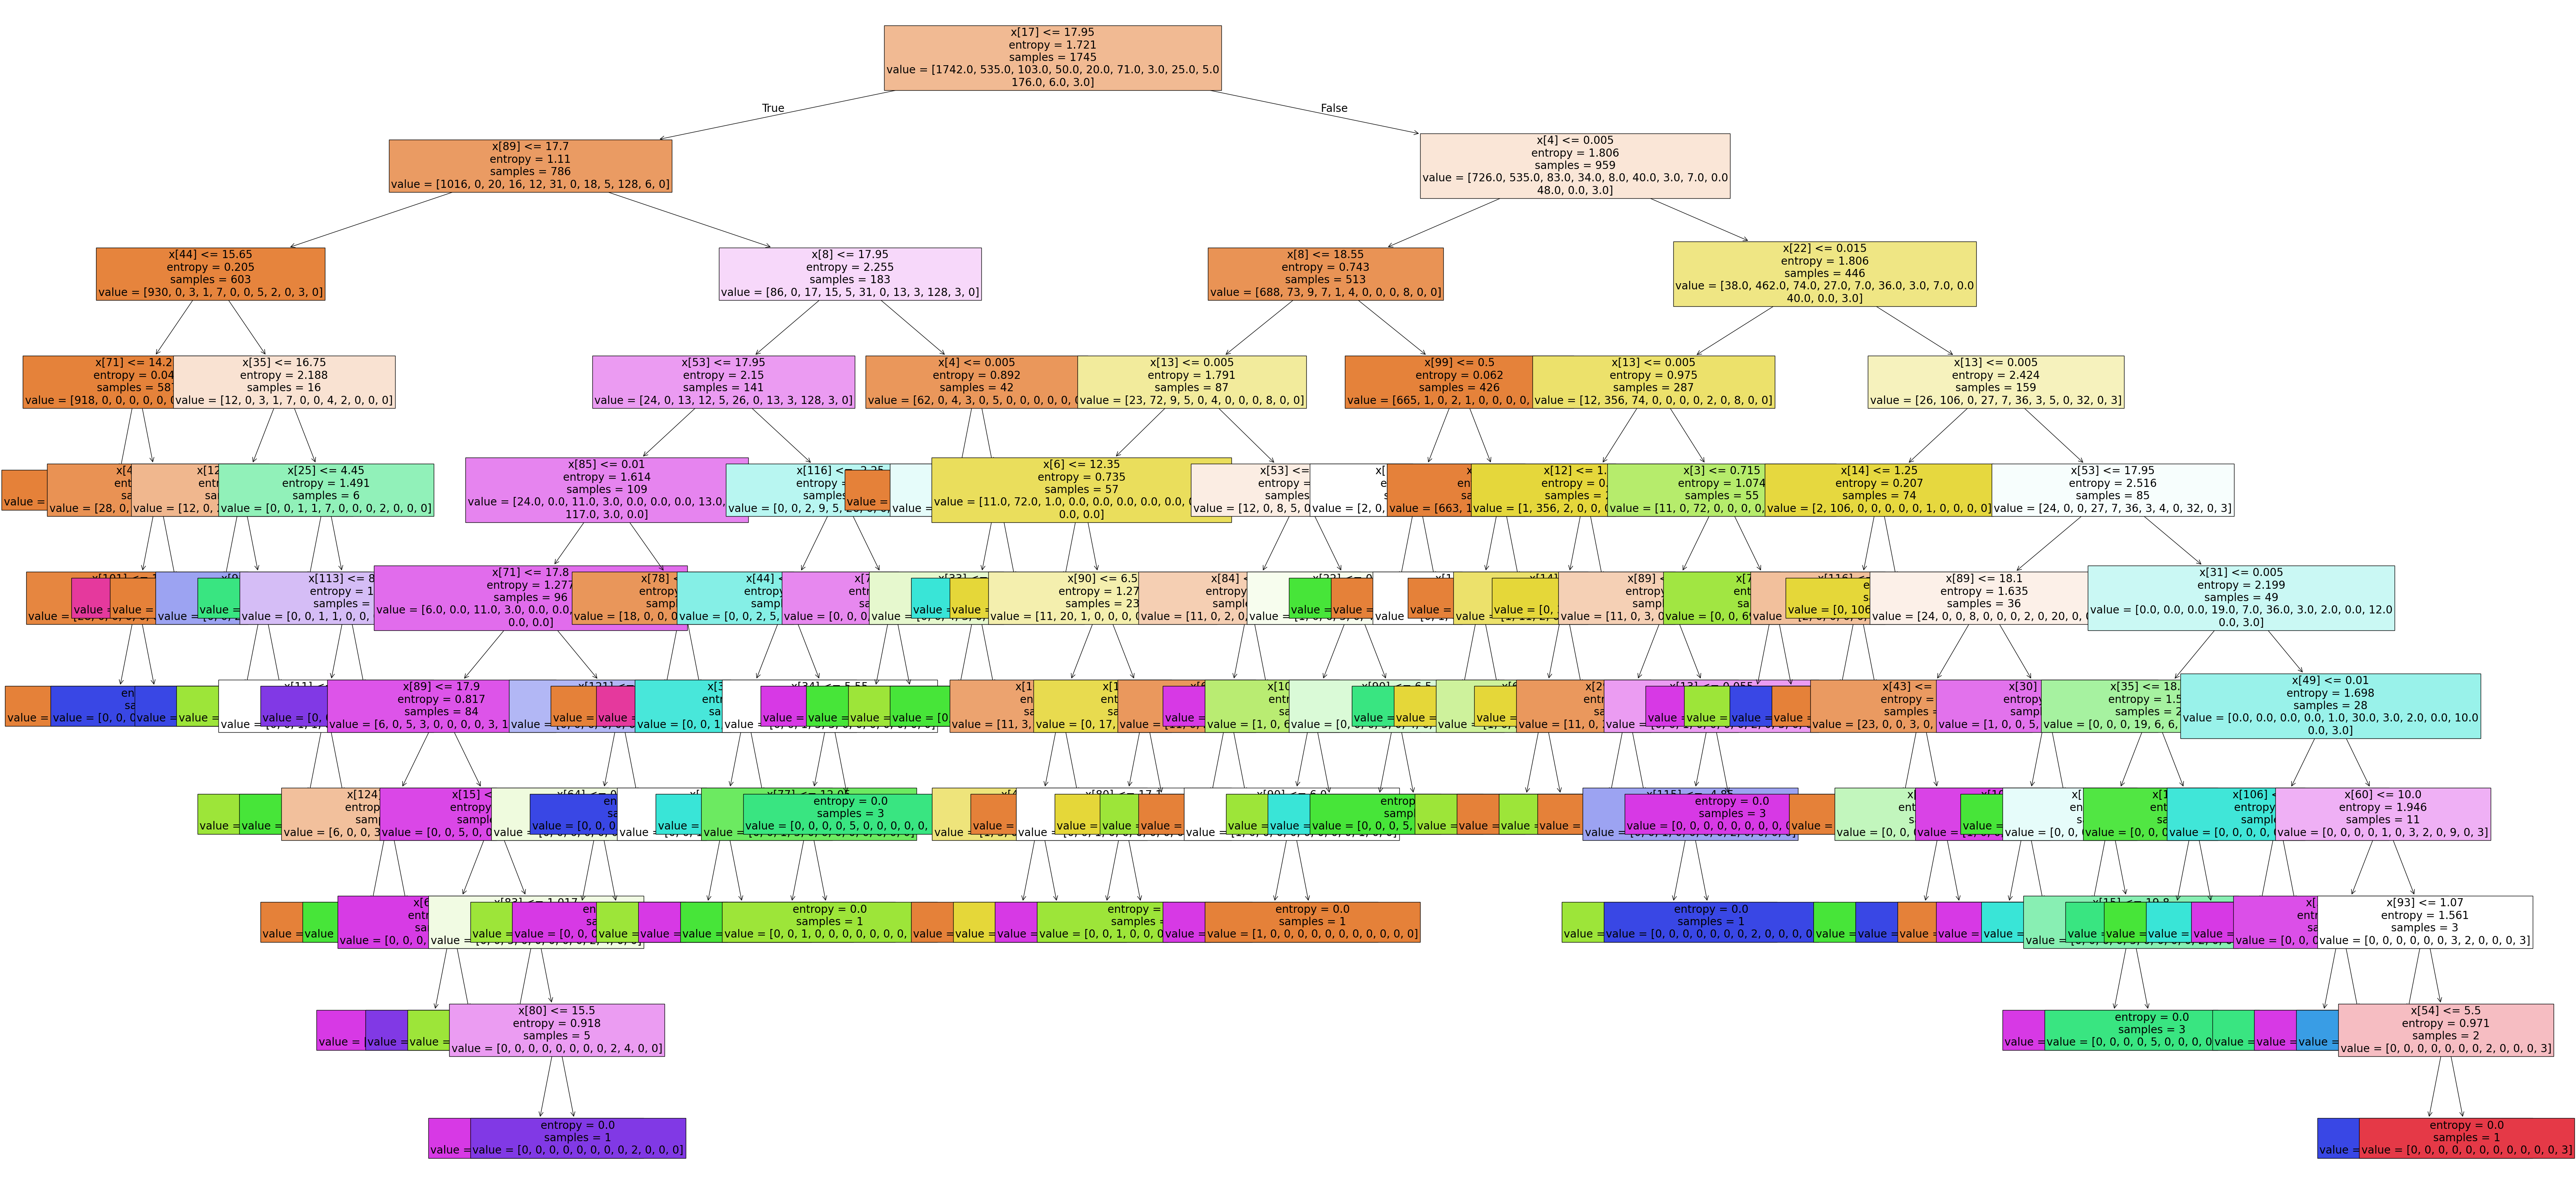

In [ ]:
# Class-names = {0:'Unpleasant Weather', 1:'Pleasant Weather'}

fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[15], fontsize = 20, filled=True);

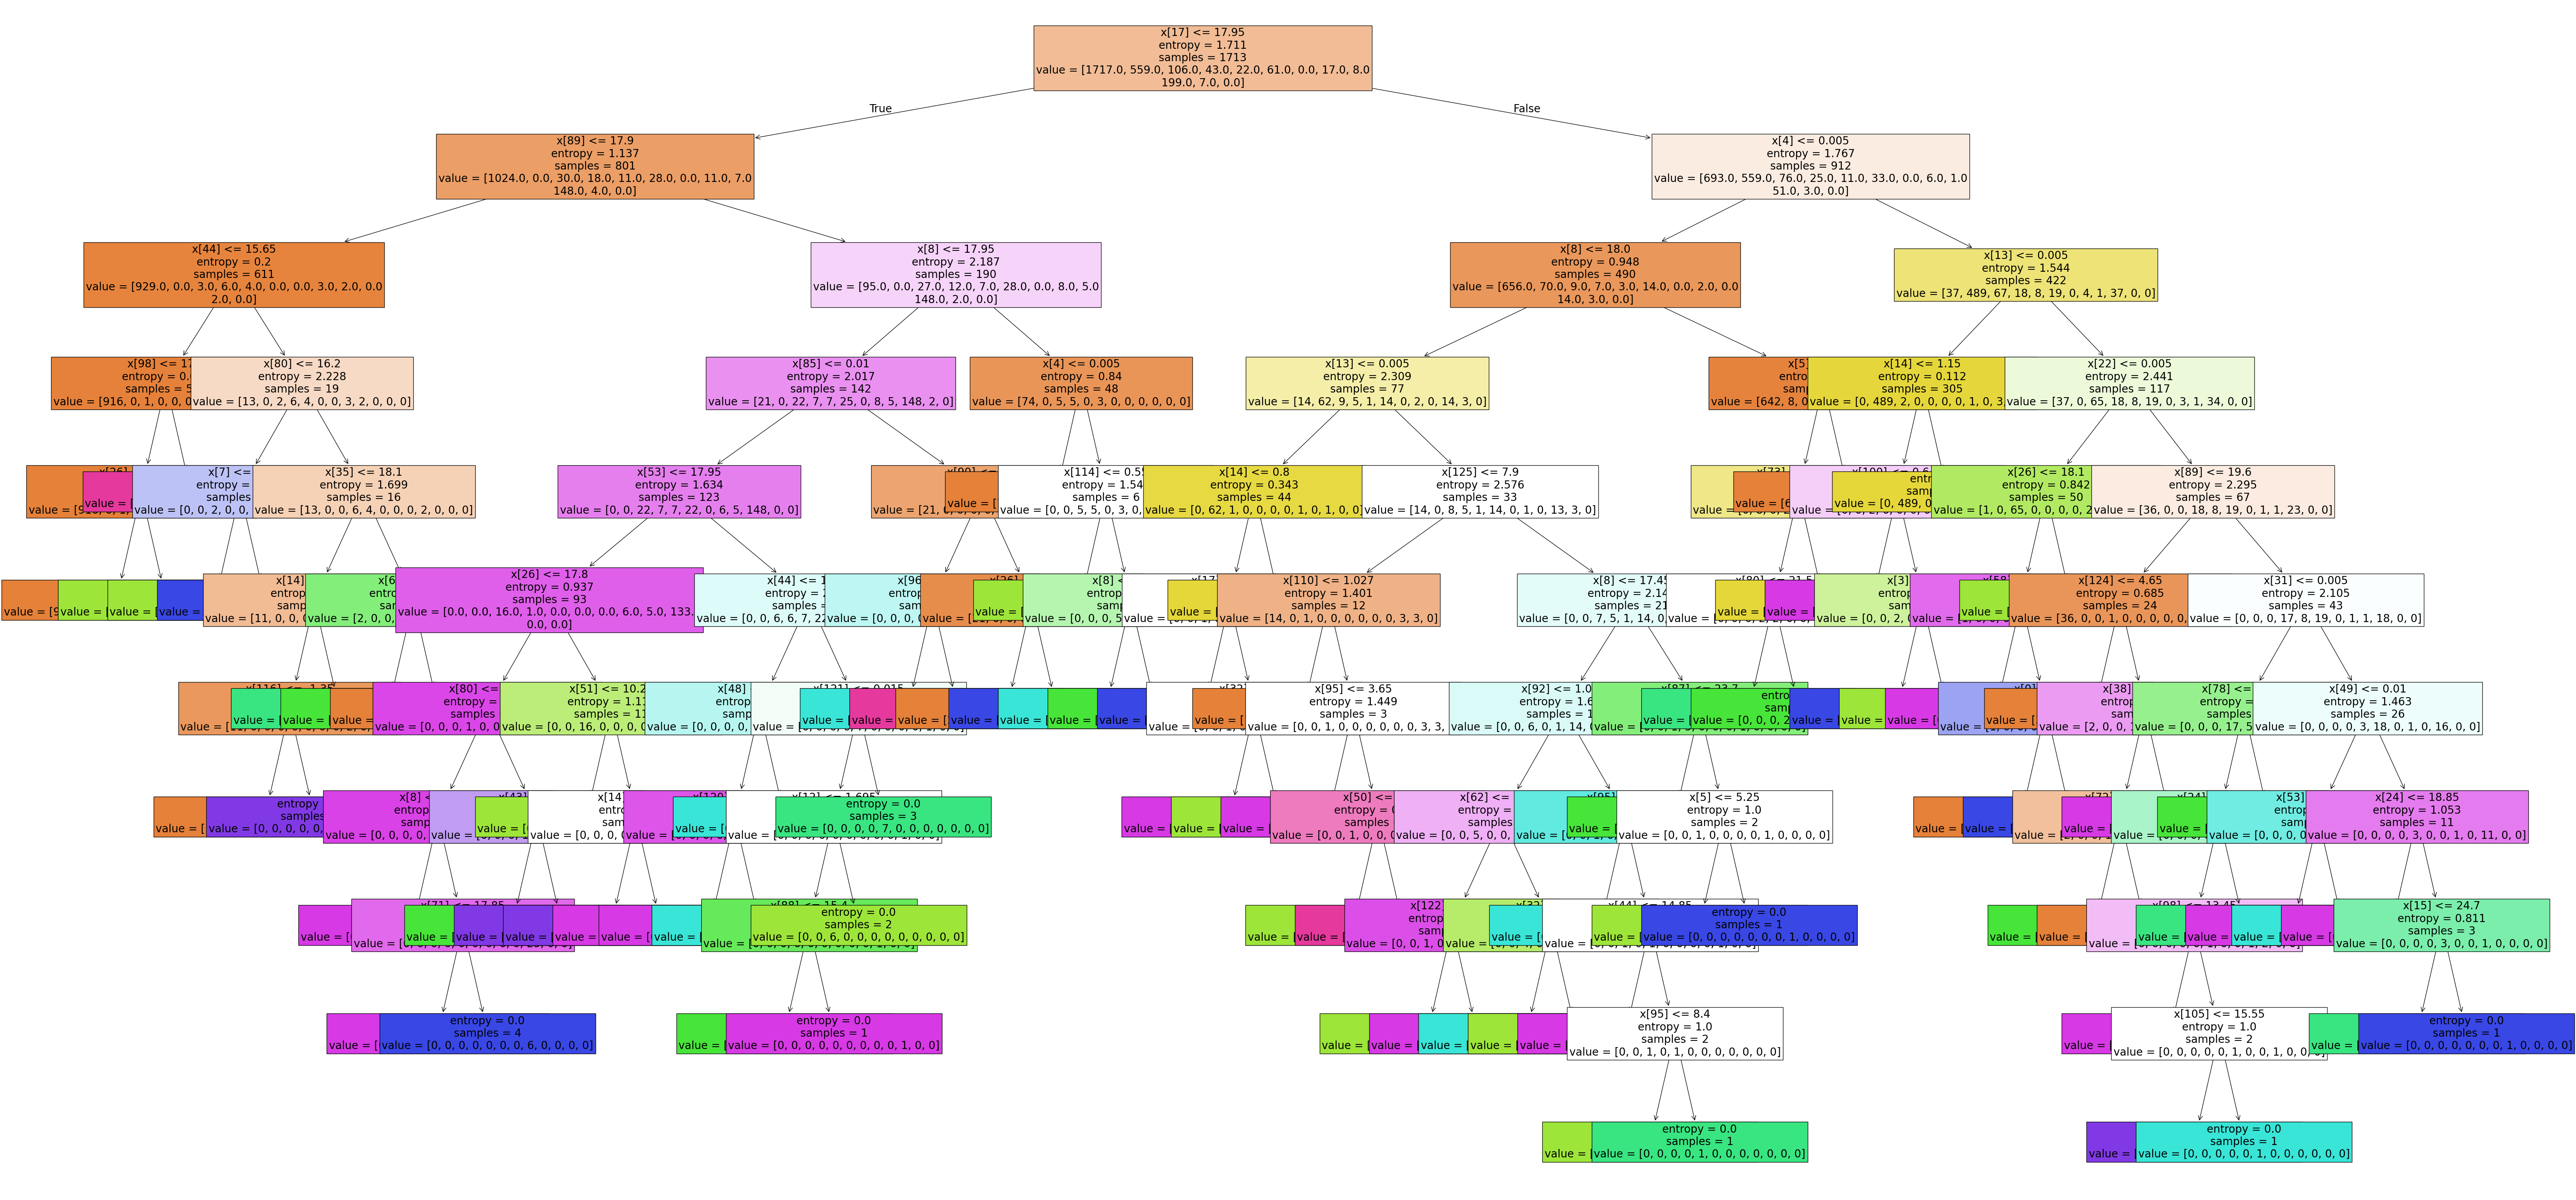

In [ ]:
# Class-names = {0:'Unpleasant Weather', 1:'Pleasant Weather'}

fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[35], fontsize = 20, filled=True);

#### 5. Feature importances

In [ ]:
np.set_printoptions(threshold=np.inf)
newarray = clf3.feature_importances_
print(clf3.feature_importances_.shape)
newarray

(135,)


array([1.27905110e-03, 8.48381518e-04, 1.02021225e-03, 1.42539951e-03,
       1.83817051e-01, 2.23952544e-02, 3.05078494e-03, 6.99327473e-04,
       8.56003122e-02, 2.10906805e-03, 1.08766286e-03, 1.03776536e-03,
       1.62197697e-03, 1.37021314e-01, 1.23121973e-02, 1.06133688e-02,
       7.32634253e-04, 1.27522620e-01, 1.23471863e-04, 0.00000000e+00,
       0.00000000e+00, 4.88740506e-04, 3.53578824e-02, 5.20490983e-04,
       2.27271454e-03, 8.90240422e-04, 2.22881520e-02, 5.70118773e-04,
       9.80772533e-04, 7.96102094e-04, 1.35171919e-03, 7.84965811e-03,
       1.15059349e-03, 1.61432371e-03, 7.53052541e-04, 1.56899054e-02,
       3.55586683e-04, 7.10650128e-04, 6.13881924e-04, 6.69556690e-04,
       2.42284862e-03, 6.31047710e-04, 1.60551528e-03, 7.76532697e-04,
       1.98606815e-02, 7.06795382e-04, 1.67770040e-03, 1.07373944e-03,
       2.77358603e-03, 4.34310078e-03, 2.01910075e-03, 1.16226215e-03,
       1.16721249e-03, 2.15690997e-02, 4.26275114e-04, 5.69457379e-04,
      

In [ ]:
np.set_printoptions(threshold=1000)

In [ ]:
newarray = newarray.reshape(-1,15,9)
print(newarray.shape)
newarray

(1, 15, 9)


array([[[1.27905110e-03, 8.48381518e-04, 1.02021225e-03, 1.42539951e-03,
         1.83817051e-01, 2.23952544e-02, 3.05078494e-03, 6.99327473e-04,
         8.56003122e-02],
        [2.10906805e-03, 1.08766286e-03, 1.03776536e-03, 1.62197697e-03,
         1.37021314e-01, 1.23121973e-02, 1.06133688e-02, 7.32634253e-04,
         1.27522620e-01],
        [1.23471863e-04, 0.00000000e+00, 0.00000000e+00, 4.88740506e-04,
         3.53578824e-02, 5.20490983e-04, 2.27271454e-03, 8.90240422e-04,
         2.22881520e-02],
        [5.70118773e-04, 9.80772533e-04, 7.96102094e-04, 1.35171919e-03,
         7.84965811e-03, 1.15059349e-03, 1.61432371e-03, 7.53052541e-04,
         1.56899054e-02],
        [3.55586683e-04, 7.10650128e-04, 6.13881924e-04, 6.69556690e-04,
         2.42284862e-03, 6.31047710e-04, 1.60551528e-03, 7.76532697e-04,
         1.98606815e-02],
        [7.06795382e-04, 1.67770040e-03, 1.07373944e-03, 2.77358603e-03,
         4.34310078e-03, 2.01910075e-03, 1.16226215e-03, 1.16721249

In [ ]:
sumarray = np.sum(newarray[0], axis=1)
sumarray

array([0.30013577, 0.29405861, 0.06194169, 0.03075625, 0.0276463 ,
       0.0364926 , 0.00486189, 0.02298812, 0.0227002 , 0.15816876,
       0.01693996, 0.00675885, 0.00830044, 0.00700545, 0.0012451 ])

In [ ]:
# Convert the set of unique stations to a list

unique_stations_list = list(unique_stations)

In [ ]:
important = pd.Series(sumarray, index = unique_stations_list)
important = important.sort_values(ascending = False)
important

,0
BASEL,0.300136
HEATHROW,0.294059
SONNBLICK,0.158169
DEBILT,0.061942
LJUBLJANA,0.036493
BUDAPEST,0.030756
MUNCHENB,0.027646
MAASTRICHT,0.022988
OSLO,0.022700
MADRID,0.016940


In [ ]:
# Create a df to associate weather stations with their importances

df_importance = pd.DataFrame({
    'Weather Station': unique_stations_list,
    'Importance': sumarray
})

df_importance = df_importance.sort_values(by='Importance', ascending = False)

['BASEL', 'HEATHROW', 'DEBILT', 'BUDAPEST', 'MUNCHENB', 'LJUBLJANA', 'KASSEL', 'MAASTRICHT', 'OSLO', 'SONNBLICK', 'MADRID', 'BELGRADE', 'VALENTIA', 'DUSSELDORF', 'STOCKHOLM']


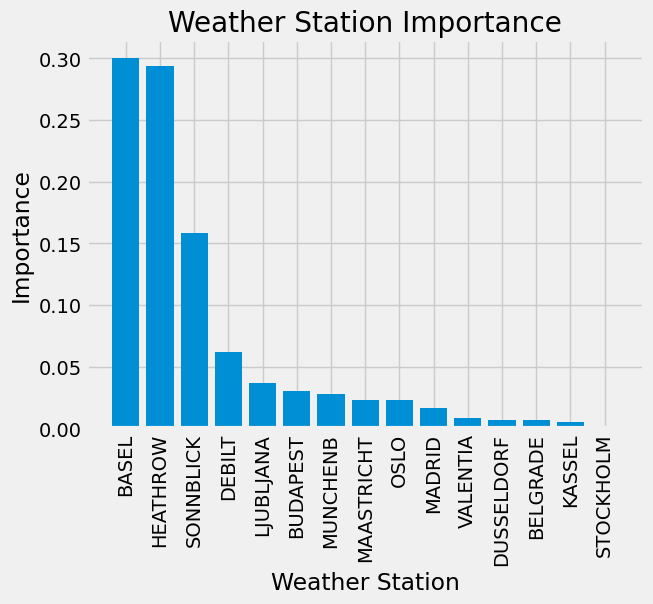

In [ ]:
# Plot the results

%matplotlib inline

plt.style.use('fivethirtyeight')
print(unique_stations_list)

plt.bar(df_importance['Weather Station'], df_importance['Importance'], orientation = 'vertical')
plt.xticks(rotation='vertical')
plt.xlabel('Weather Station')
plt.ylabel('Importance')
plt.title('Weather Station Importance')

plt.show()